# Análisis exploratorio de los datos
Este notebook se encarga de analizar los datos. Desde la creación de dataframes con información de cromosomas e imagenes, hasta la obtención de información de los datos.

## 1. Organización y creación de dataframes
Organizamos los datos para generar un dataframe con la información de los cromosomas de las imagenes y un dataframe con la información de las imagenes.

In [ ]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
# ==========================================================
# CONFIGURACIÓN
# ==========================================================
# Carpeta donde están los archivos XML
data_path = Path('../../data/raw')
ANNOTATIONS_DIR = data_path / 'annotations'

# Carpeta donde se guardarán los CSV
OUTPUT_DIR = Path.cwd()

# ==========================================================
# LISTAS PARA ALMACENAR LOS REGISTROS
# ==========================================================
images_data = []
chromosomes_data = []

# ID incremental global para cada cromosoma
chromosome_id = 1

# ==========================================================
# RECORRER TODOS LOS ARCHIVOS XML
# ==========================================================
for file in os.listdir(ANNOTATIONS_DIR):

    # Procesar únicamente archivos .xml
    if not file.lower().endswith(".xml"):
        continue

    xml_path = os.path.join(ANNOTATIONS_DIR, file)

    # Parsear XML
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # ------------------------------------------------------
    # EXTRAER INFORMACIÓN DE LA IMAGEN
    # ------------------------------------------------------
    # Nombre de archivo de imagen (ej. 103064.jpg)
    file_name = root.find("filename").text

    # ID de imagen = nombre del archivo sin extensión
    id_image = os.path.splitext(file_name)[0]

    # Tamaño de la imagen
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    # Agregar registro al dataframe images
    images_data.append({
        "id_image": id_image,
        "file_name": file_name,
        "width": width,
        "height": height
    })

    # ------------------------------------------------------
    # EXTRAER INFORMACIÓN DE LOS CROMOSOMAS
    # ------------------------------------------------------
    for obj in root.findall("object"):
        label = obj.find("name").text

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        chromosomes_data.append({
            "id_chromosome": chromosome_id,
            "id_image": id_image,
            "etiqueta": label,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax
        })

        chromosome_id += 1

# ==========================================================
# CREAR DATAFRAMES
# ==========================================================
df_images = pd.DataFrame(images_data)
df_chromosomes = pd.DataFrame(chromosomes_data)

# ==========================================================
# GUARDAR CSV
# ==========================================================
images_csv = os.path.join(OUTPUT_DIR, "images.csv")
chromosomes_csv = os.path.join(OUTPUT_DIR, "chromosomes.csv")
print("Proceso completado exitosamente.")
print(f"Imágenes procesadas: {len(df_images)}")
print(f"Cromosomas extraídos: {len(df_chromosomes)}")

..\..\data\raw\annotations c:\Users\Acer\Desktop\API\sibun_ag\Chromosome-identifier-TDSP\scripts\data_analytics


Con esto ya hemos generado los archivos csv "images" y "chromosomes", que contienen la información de los datos de manera más organizada y limpia. Finalmente cargamos los csv como dataframes para realizar su análisis.

In [ ]:
df_images = pd.read_csv('images.csv')
df_chromosomes = pd.read_csv('chromosomes.csv')


=== DataFrame Images ===
  id_image   file_name  width  height
0   103064  103064.jpg    524     581
1   103071  103071.jpg    644     709
2   103072  103072.jpg    637     590
3   103081  103081.jpg    658     586
4   103082  103082.jpg   1134     759

=== DataFrame Chromosomes ===
   id_chromosome id_image etiqueta  xmin  ymin  xmax  ymax
0              1   103064       A1   237   274   303   393
1              2   103064       A1    91   205   200   302
2              3   103064       A2   378   214   464   281
3              4   103064       A2   144   313   205   419
4              5   103064       A3   169   248   243   322


## 2. Análisis de los dataframes
Utilizando los dataframes generados realizamos un análisis en busqueda de nulos, tipos, max,mins y otras caracteristicas.

In [ ]:
pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Acer\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


INFORMACIÓN GENERAL

--- df_images ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_image   5000 non-null   object
 1   file_name  5000 non-null   object
 2   width      5000 non-null   int64 
 3   height     5000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 156.4+ KB
None

--- df_chromosomes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229852 entries, 0 to 229851
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id_chromosome  229852 non-null  int64 
 1   id_image       229852 non-null  object
 2   etiqueta       229852 non-null  object
 3   xmin           229852 non-null  int64 
 4   ymin           229852 non-null  int64 
 5   xmax           229852 non-null  int64 
 6   ymax           229852 non-null  int64 
 7   bbox_width     229852 non-nu

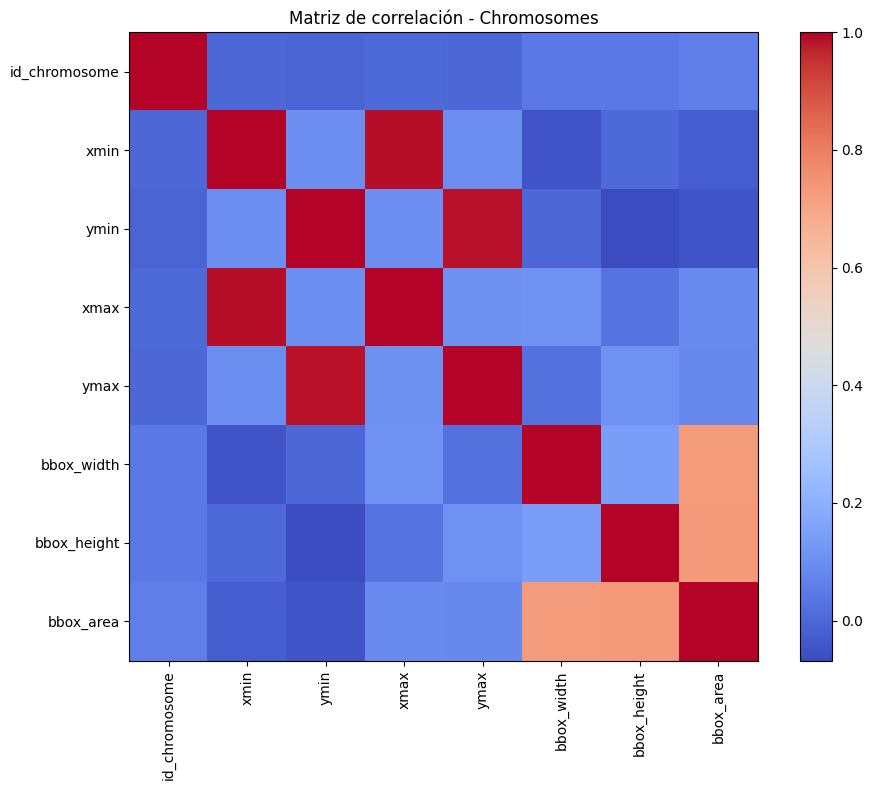

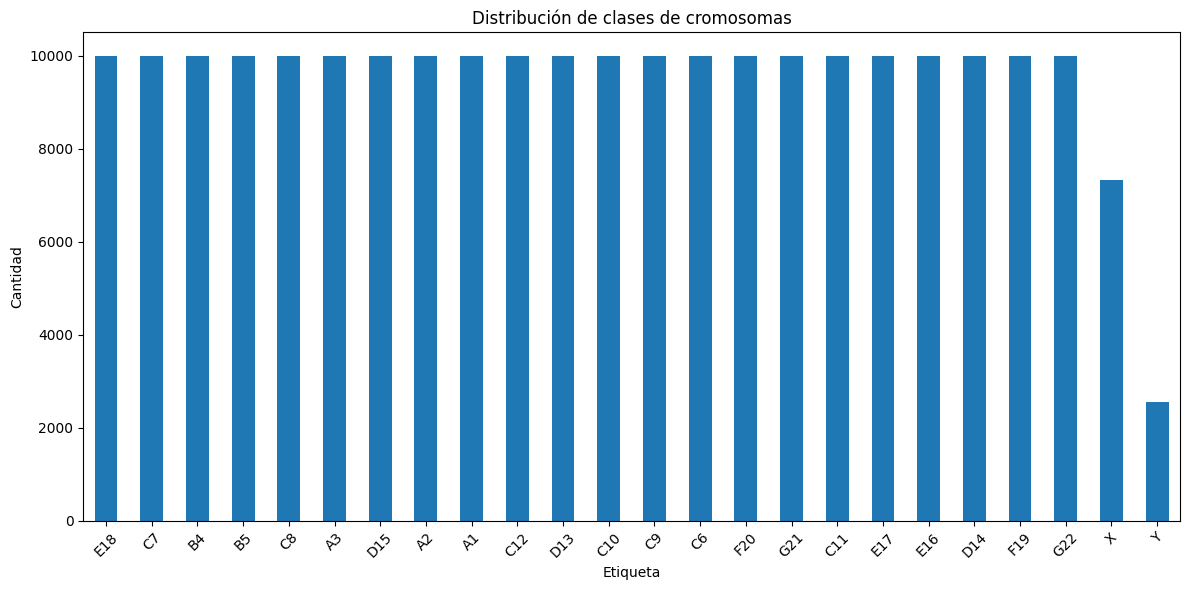


ESTADÍSTICAS BOUNDING BOX
          bbox_width    bbox_height      bbox_area
count  229852.000000  229852.000000  229852.000000
mean       71.621169      71.179833    5237.682474
std        31.178588      31.194482    3594.965040
min        16.000000      17.000000     440.000000
25%        47.000000      47.000000    2597.000000
50%        65.000000      65.000000    4288.000000
75%        90.000000      89.000000    6784.000000
max       317.000000     268.000000   43884.000000


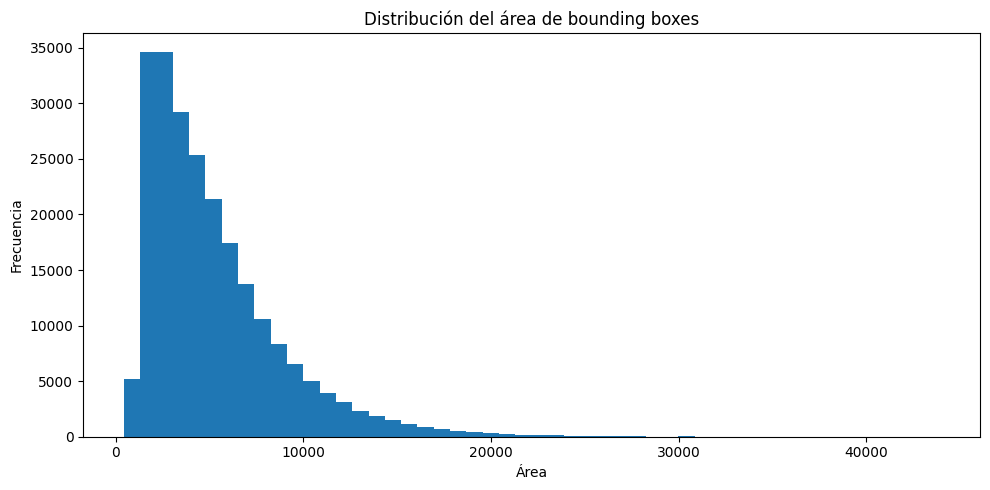


CROMOSOMAS POR IMAGEN
count    5000.000000
mean       45.970400
std         0.311036
min        43.000000
25%        46.000000
50%        46.000000
75%        46.000000
max        50.000000
dtype: float64


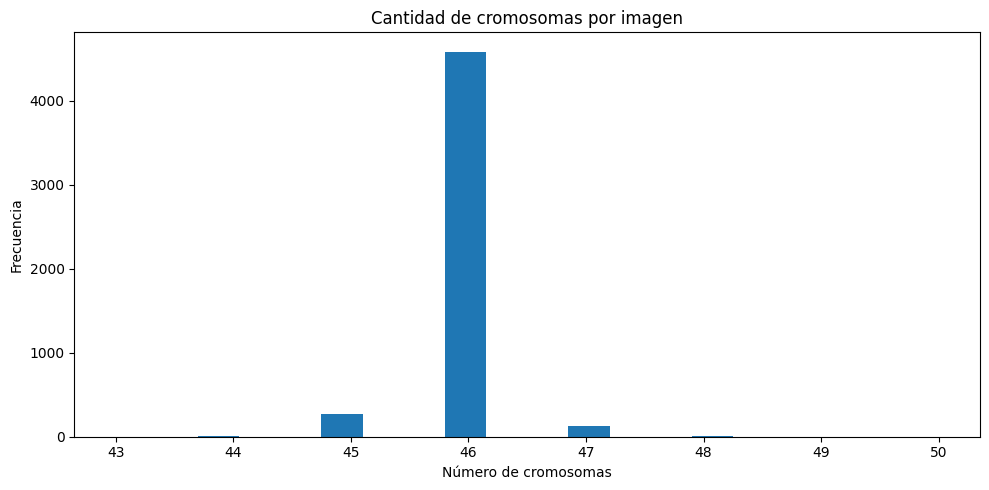


VALIDACIÓN DE COORDENADAS
Bounding boxes inválidos: 0


In [ ]:
# ==========================================================
# ANÁLISIS EXPLORATORIO (EDA)
# DataFrames:
#   - df_images
#   - df_chromosomes
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. INFORMACIÓN GENERAL
# ==========================================================

print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.info())

print("\n--- df_chromosomes ---")
print(df_chromosomes.info())

print("\n" + "=" * 60)
print("RESUMEN ")
print("=" * 60)

print(f"Total imágenes: {len(df_images)}")
print(f"Total cromosomas: {len(df_chromosomes)}")
print(f"Clases únicas: {df_chromosomes['etiqueta'].nunique()}")

print("\nEtiquetas únicas:")
print(sorted(df_chromosomes["etiqueta"].unique()))
# ==========================================================
# 2. PRIMERAS FILAS
# ==========================================================

print("\n" + "=" * 60)
print("PRIMERAS FILAS")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.head())

print("\n--- df_chromosomes ---")
print(df_chromosomes.head())

# ==========================================================
# 3. VALORES NULOS
# ==========================================================

print("\n" + "=" * 60)
print("VALORES NULOS")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.isnull().sum())

print("\n--- df_chromosomes ---")
print(df_chromosomes.isnull().sum())

# ==========================================================
# 4. DUPLICADOS
# ==========================================================

print("\n" + "=" * 60)
print("DUPLICADOS")
print("=" * 60)

print("\nDuplicados en df_images:")
print(df_images.duplicated().sum())

print("\nDuplicados en df_chromosomes:")
print(df_chromosomes.duplicated().sum())

# ==========================================================
# 5. ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

print("\n--- df_images ---")
print(df_images.describe())

print("\n--- df_chromosomes ---")
print(df_chromosomes.describe())

# ==========================================================
# 6. VALORES MÍNIMOS Y MÁXIMOS
# ==========================================================

print("\n" + "=" * 60)
print("VALORES MÍNIMOS Y MÁXIMOS")
print("=" * 60)

columnas_numericas_images = df_images.select_dtypes(include='number').columns
columnas_numericas_chrom = df_chromosomes.select_dtypes(include='number').columns

print("\n--- df_images ---")
for col in columnas_numericas_images:
    print(f"{col}: min={df_images[col].min()} | max={df_images[col].max()}")

print("\n--- df_chromosomes ---")
for col in columnas_numericas_chrom:
    print(f"{col}: min={df_chromosomes[col].min()} | max={df_chromosomes[col].max()}")

# ==========================================================
# 7. DISTRIBUCIÓN DE CLASES (ETIQUETAS)
# ==========================================================

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 60)

conteo_etiquetas = df_chromosomes["etiqueta"].value_counts()

print(conteo_etiquetas)

# ==========================================================
# 8. CORRELACIONES
# ==========================================================

print("\n" + "=" * 60)
print("MATRIZ DE CORRELACIÓN")
print("=" * 60)

correlation = df_chromosomes.select_dtypes(include='number').corr()

print(correlation)

# ==========================================================
# 9. VISUALIZACIÓN DE CORRELACIÓN
# ==========================================================

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Matriz de correlación - Chromosomes")

plt.tight_layout()
plt.show()

# ==========================================================
# 10. HISTOGRAMA DE ETIQUETAS
# ==========================================================

plt.figure(figsize=(12, 6))

conteo_etiquetas.plot(kind='bar')

plt.title("Distribución de clases de cromosomas")
plt.xlabel("Etiqueta")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================================
# 11. TAMAÑO DE BOUNDING BOXES
# ==========================================================

# Ancho y alto del bounding box
df_chromosomes["bbox_width"] = (
    df_chromosomes["xmax"] - df_chromosomes["xmin"]
)

df_chromosomes["bbox_height"] = (
    df_chromosomes["ymax"] - df_chromosomes["ymin"]
)

# Área
df_chromosomes["bbox_area"] = (
    df_chromosomes["bbox_width"] *
    df_chromosomes["bbox_height"]
)

print("\n" + "=" * 60)
print("ESTADÍSTICAS BOUNDING BOX")
print("=" * 60)

print(df_chromosomes[
    ["bbox_width", "bbox_height", "bbox_area"]
].describe())

# ==========================================================
# 12. HISTOGRAMA ÁREAS
# ==========================================================

plt.figure(figsize=(10, 5))

plt.hist(df_chromosomes["bbox_area"], bins=50)

plt.title("Distribución del área de bounding boxes")
plt.xlabel("Área")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# ==========================================================
# 13. CANTIDAD DE CROMOSOMAS POR IMAGEN
# ==========================================================

chromosomes_per_image = (
    df_chromosomes.groupby("id_image")
    .size()
)

print("\n" + "=" * 60)
print("CROMOSOMAS POR IMAGEN")
print("=" * 60)

print(chromosomes_per_image.describe())

plt.figure(figsize=(10, 5))

plt.hist(chromosomes_per_image, bins=20)

plt.title("Cantidad de cromosomas por imagen")
plt.xlabel("Número de cromosomas")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Tras la carga y revisión general de los DataFrames, podemos destacar los siguientes hallazgos positivos sobre la calidad del dataset:

* **Volumen de datos:** Contamos con un total de **5000** imágenes y **229,852** cromosomas extraídos.
* **Limpieza absoluta:** No se encontraron valores nulos (NaN) ni registros duplicados en ninguno de los dos conjuntos de datos. Esto indica que el proceso de parsing del XML fue altamente efectivo y los datos están listos para ser procesados sin necesidad de imputaciones.
* **Clasificación:** Existen **24 clases únicas** de cromosomas, lo que corresponde a la representación esperada de un cariotipo humano completo (22 pares de autosomas, más los cromosomas sexuales X e Y).

**Análisis de Dimensiones (Imágenes y Bounding Boxes)**
Las estadísticas descriptivas revelan la variabilidad en las resoluciones y en los tamaños de los cromosomas:

| Característica | Media | Mínimo | Máximo |
| :--- | :--- | :--- | :--- |
| **Ancho de Imagen** | 749 px | 360 px | 1360 px |
| **Alto de Imagen** | 708 px | 383 px | 1024 px |
| **Ancho BBox** | ~71.6 px | 16 px | 317 px |
| **Alto BBox** | ~71.1 px | 17 px | 268 px |
| **Área BBox** | ~5237 px² | 440 px² | 43884 px² |

**Observación clave:** Existe una gran variabilidad en el tamaño de las imágenes originales, lo que sugiere que para entrenar un modelo de Deep Learning será necesario aplicar técnicas de _resizing_ o _padding_ para estandarizar las entradas. Así mismo, las dimensiones de los Bounding Boxes varían significativamente, lo cual es biológicamente correcto (los cromosomas varían drásticamente en tamaño, desde el Cromosoma 1 hasta el Cromosoma Y).

**Distribución de Clases de Cromosomas**
Al analizar el conteo de etiquetas, se observa un dataset **altamente balanceado** para los cromosomas autosómicos:

* **Autosomas (A1 a G22):** Cada clase ronda de manera casi perfecta las **10,000 instancias** (entre 9,993 y 10,003).
* **Cromosomas Sexuales:** La clase **X** tiene **7,334** instancias y la clase **Y** tiene **2,564**. Esta desproporción no es un problema del dataset, sino un reflejo de la biología y la demografía de la muestra (las mujeres tienen dos cromosomas X, mientras que los hombres tienen un X y un Y).

**Distribución de Cromosomas por Cariotipo**
El análisis del número de cromosomas por imagen nos sirve como control de calidad biológico del dataset:
* **Media:** Se detectan en promedio **~46 cromosomas** por imagen, lo cual coincide exactamente con la cantidad de cromosomas en una célula somática humana normal.
* **Rango:** El número varía entre **43 y 50**. Las pequeñas variaciones por debajo o por encima de 46 pueden deberse a artefactos de la imagen (cromosomas superpuestos no detectados por el anotador), células incompletas en el frotis, o posibles casos reales de aneuploidías (alteraciones en el número de cromosomas).

---

A continuación realizamos un análisis a nivel de imágen y distribución de los cromosomas

In [ ]:
import glob
import os
import xml.etree.ElementTree as ET

import pandas as pd

xml_files = sorted(glob.glob(os.path.join(data_path = Path('../../data/raw/annotations'), "*.xml")))
rows = []

for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.findtext("filename")
    folder = root.findtext("folder")
    width = int(root.findtext("size/width"))
    height = int(root.findtext("size/height"))
    depth = int(root.findtext("size/depth", default="0"))

    chromosome_counts = {}
    chromosome_areas = []
    x_present = False
    y_present = False

    for obj in root.findall("object"):
        name = obj.findtext("name")
        xmin = int(obj.findtext("bndbox/xmin"))
        ymin = int(obj.findtext("bndbox/ymin"))
        xmax = int(obj.findtext("bndbox/xmax"))
        ymax = int(obj.findtext("bndbox/ymax"))
        area = max(0, xmax - xmin) * max(0, ymax - ymin)

        chromosome_counts[name] = chromosome_counts.get(name, 0) + 1
        chromosome_areas.append((name, area))

        if name == "X":
            x_present = True
        elif name == "Y":
            y_present = True

    total_image_area = width * height if width and height else 1
    sex = "Unknown"
    if x_present and y_present:
        sex = "Male"
    elif x_present and not y_present:
        sex = "Female"
    elif not x_present and y_present:
        sex = "Male"

    for chromosome_name, area in chromosome_areas:
        rows.append({
            "xml_file": os.path.basename(xml_file),
            "folder": folder,
            "filename": filename,
            "image_width": width,
            "image_height": height,
            "image_depth": depth,
            "chromosome": chromosome_name,
            "chromosome_area": area,
            "area_ratio": area / total_image_area,
            "image_area": total_image_area,
            "duplicated_in_image": chromosome_counts[chromosome_name] > 1,
            "chromosome_count": chromosome_counts[chromosome_name],
            "sex_based_on_xy": sex,
            "annotations_path": xml_file,
            "image_path": os.path.join(IMAGES_PATH, filename) if filename else None,
        })

chromosome_df = pd.DataFrame(rows)

# Resumen rápido
summary = chromosome_df.groupby(["xml_file", "filename"]).agg(
    image_width=("image_width", "first"),
    image_height=("image_height", "first"),
    image_depth=("image_depth", "first"),
    num_chromosome_annotations=("chromosome", "count"),
    unique_chromosome_labels=("chromosome", lambda x: sorted(set(x))),
    num_distinct_chromosomes=("chromosome", "nunique"),
    duplicated_chromosomes=("duplicated_in_image", "sum"),
    sex_based_on_xy=("sex_based_on_xy", "first"),
).reset_index()

chromosome_df.head(15), summary.head(10)


(      xml_file               folder    filename  image_width  image_height  \
 0   103064.xml  chromosome_original  103064.jpg          524           581   
 1   103064.xml  chromosome_original  103064.jpg          524           581   
 2   103064.xml  chromosome_original  103064.jpg          524           581   
 3   103064.xml  chromosome_original  103064.jpg          524           581   
 4   103064.xml  chromosome_original  103064.jpg          524           581   
 5   103064.xml  chromosome_original  103064.jpg          524           581   
 6   103064.xml  chromosome_original  103064.jpg          524           581   
 7   103064.xml  chromosome_original  103064.jpg          524           581   
 8   103064.xml  chromosome_original  103064.jpg          524           581   
 9   103064.xml  chromosome_original  103064.jpg          524           581   
 10  103064.xml  chromosome_original  103064.jpg          524           581   
 11  103064.xml  chromosome_original  103064.jpg    

In [ ]:
grouped_counts = chromosome_df.groupby(["chromosome", "chromosome_count"]).size().reset_index(name="count")
grouped_counts

,chromosome,chromosome_count,count
0,A1,1,1
1,A1,2,9998
2,A2,2,10000
3,A3,1,2
4,A3,2,9992
...,...,...,...
59,X,1,2619
60,X,2,4700
61,X,3,15
62,Y,1,2534


In [ ]:
sex_counts = summary.groupby("sex_based_on_xy")["xml_file"].nunique().reset_index(name="unique_person_count")
sex_counts

,sex_based_on_xy,unique_person_count
0,Female,2445
1,Male,2549
2,Unknown,6


In [ ]:
non_xy_non_two = chromosome_df[(~chromosome_df["chromosome"].isin(["X", "Y"])) & (chromosome_df["chromosome_count"] != 2)]

# Contar cada persona una sola vez usando xml_file como identificador único de persona
unique_persons_non_xy_non_two = non_xy_non_two.drop_duplicates(subset=["xml_file"])
counts_non_xy_non_two = unique_persons_non_xy_non_two["sex_based_on_xy"].value_counts().rename_axis("sex").reset_index(name="unique_person_count")
counts_non_xy_non_two

,sex,unique_person_count
0,Male,66
1,Female,57


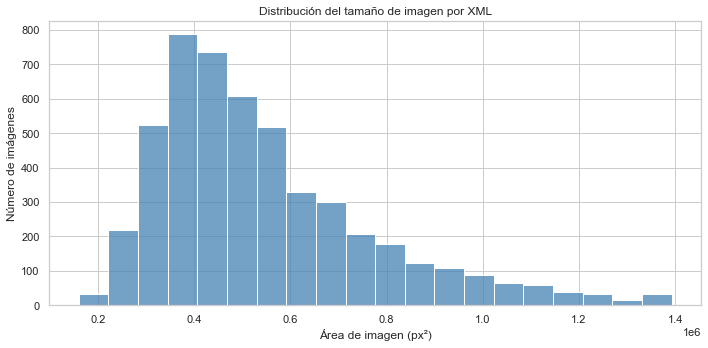

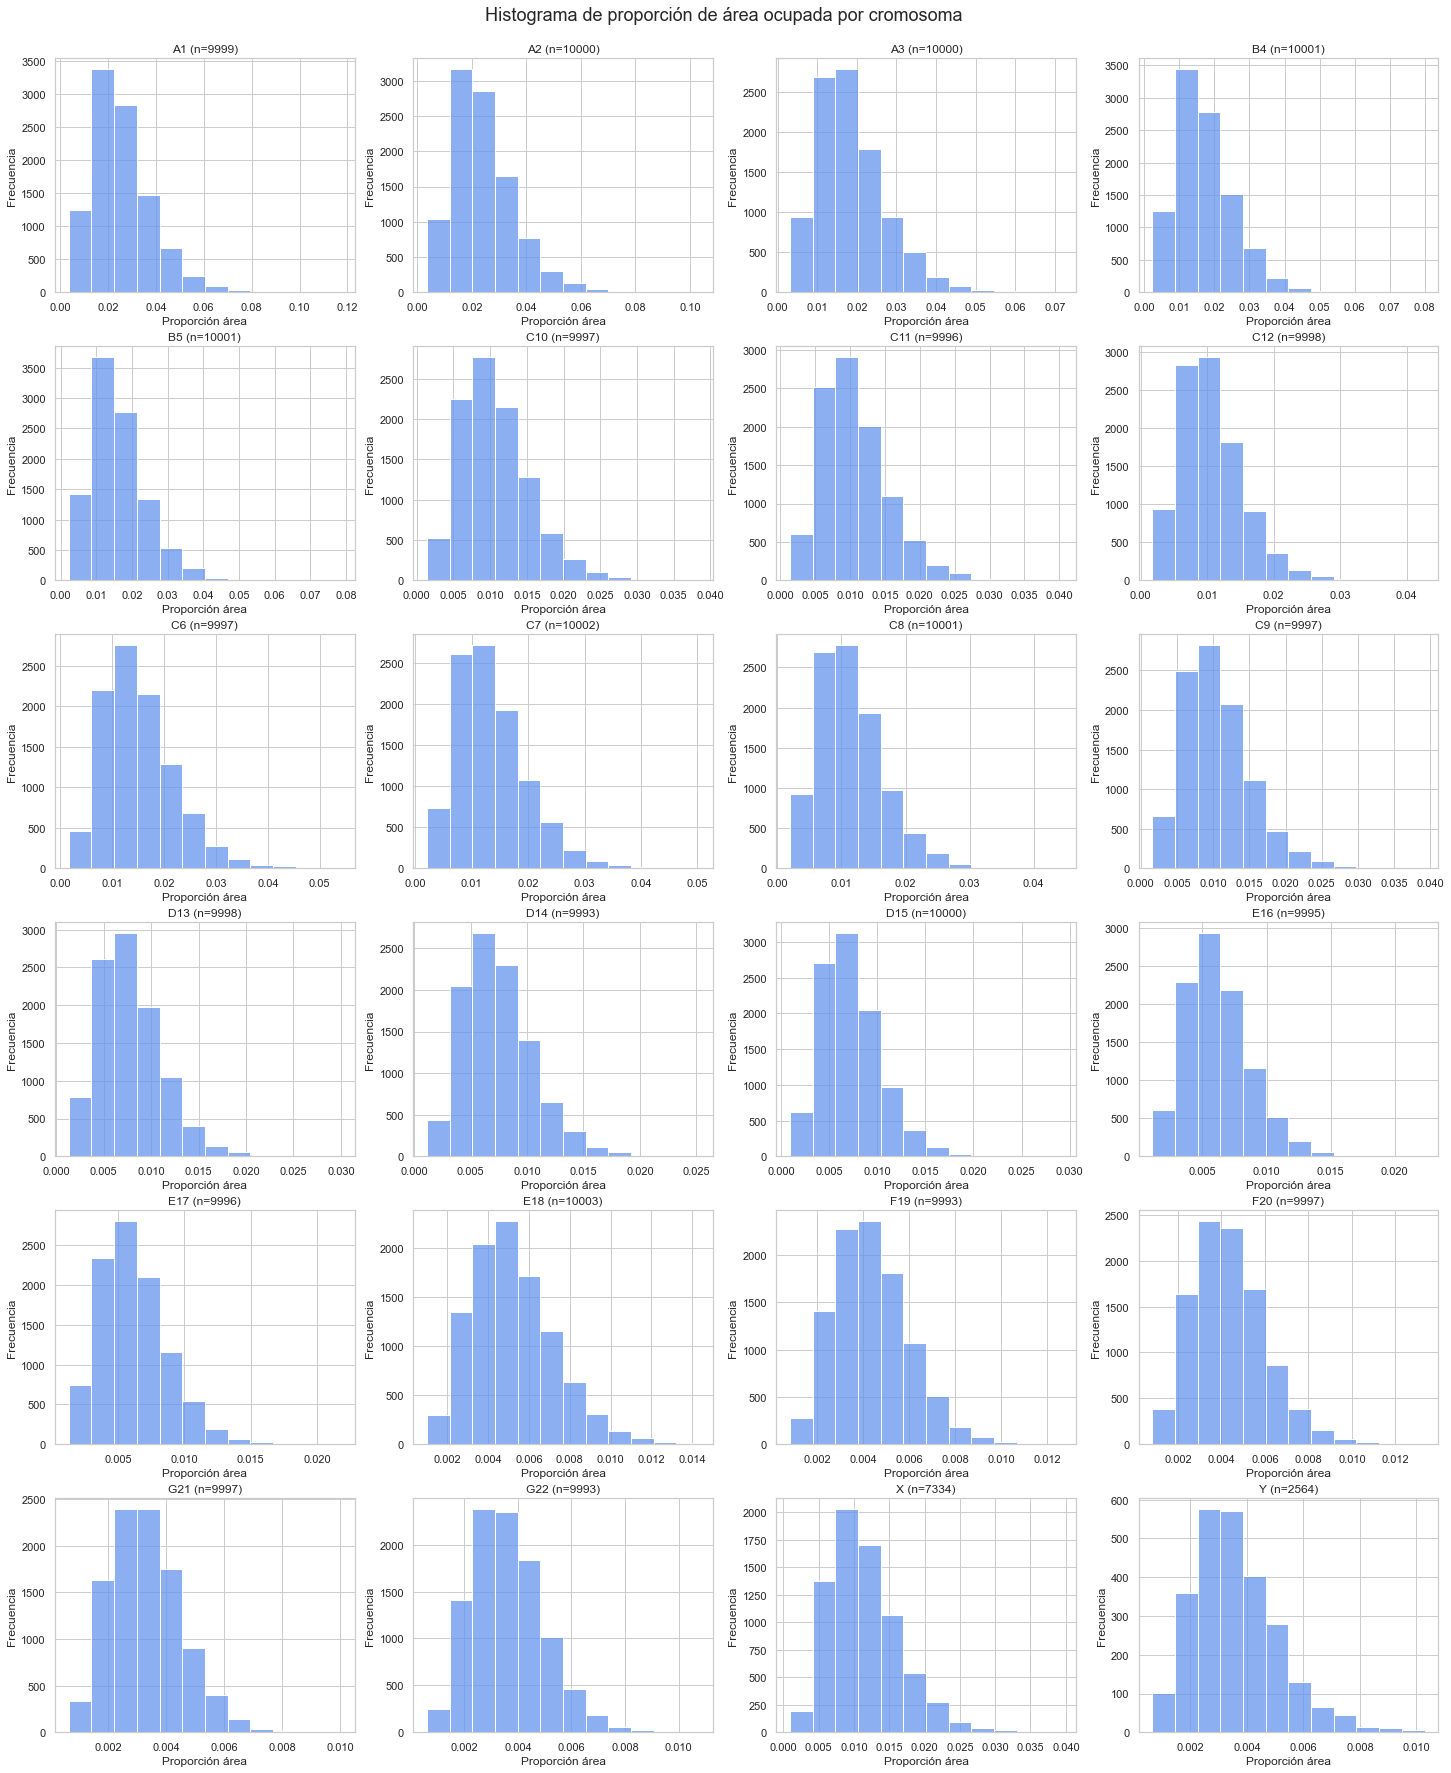

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Histograma del tamaño de imagen por XML
summary["image_area"] = summary["image_width"] * summary["image_height"]
plt.figure(figsize=(10, 5))
sns.histplot(summary["image_area"], bins=20, kde=False, color="steelblue")
plt.title("Distribución del tamaño de imagen por XML")
plt.xlabel("Área de imagen (px²)")
plt.ylabel("Número de imágenes")
plt.tight_layout()
plt.show()

# Agrupar por cromosoma y mostrar un resumen
chromosome_summary = chromosome_df.groupby("chromosome").agg(
    count=("chromosome", "size"),
    mean_area_ratio=("area_ratio", "mean"),
    median_area_ratio=("area_ratio", "median"),
).reset_index()
chromosome_summary

# Histograma de proporción de área ocupada por cada cromosoma
chromosomes = sorted(chromosome_df["chromosome"].unique())
num_chromosomes = len(chromosomes)
cols = 4
rows = (num_chromosomes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4), constrained_layout=True)
axes = axes.flatten()

for ax, chrom in zip(axes, chromosomes):
    data = chromosome_df.loc[chromosome_df["chromosome"] == chrom, "area_ratio"]
    sns.histplot(data, bins=12, kde=False, ax=ax, color="cornflowerblue")
    ax.set_title(f"{chrom} (n={len(data)})")
    ax.set_xlabel("Proporción área")
    ax.set_ylabel("Frecuencia")

for ax in axes[num_chromosomes:]:
    ax.axis("off")

fig.suptitle("Histograma de proporción de área ocupada por cromosoma", fontsize=18, y=1.02)
plt.show()

**Proporción de Área y Demografía de la Muestra**
A partir de los metadatos y la presencia de cromosomas sexuales en cada imagen, logramos reconstruir información de alto nivel sobre la muestra clínica:

* **Balance Demográfico (Sexo):** El dataset proviene de **2549 muestras masculinas** (presencia de X e Y) y **2445 muestras femeninas** (presencia de X, ausencia de Y). Existen solo 6 muestras clasificadas como "Desconocidas", lo que nos confirma que los datos provienen de una cohorte de pacientes sumamente equilibrada.
* **Proporción de Área por Cromosoma:** Los histogramas de distribución de área demuestran claramente los grupos citogenéticos. Cromosomas grandes (como el **A1** o **A2**) ocupan una mayor proporción relativa del área total de la imagen, mientras que cromosomas más pequeños (como el **G21**, **G22** o el **Y**) tienen curvas de distribución desplazadas hacia valores mucho menores. Esto servirá como un excelente _feature_ subyacente para los algoritmos de detección u ordenamiento.